# StreamFlix — Phase 2 Exploratory Data Analysis

## Objective

The objective of Phase 2 is to explore StreamFlix viewing,
subscriber, content, device, and review data using visualizations.

This phase contains 10 EDA charts covering:
1. Monthly Viewing Volume
2. Monthly Watch Hours Trend
3. Genre-wise Watch Hours Share
4. Content Type Split
5. Top 10 Countries by Watch Hours
6. Subscriber Plan Distribution
7. Device Usage
8. Age Distribution
9. Completion Rate by Genre
10. Review Sentiment Breakdown

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
DATA_PATH = r"C:\Users\ASUS\Desktop\Internmo\Project - 3\cleaned_data"

print("Data folder:", DATA_PATH)
print("Folder exists:", os.path.exists(DATA_PATH))

Data folder: C:\Users\ASUS\Desktop\Internmo\Project - 3\cleaned_data
Folder exists: True


### Load all cleaned datasets

In [11]:
print("Files inside cleaned_data folder:\n")

for file in os.listdir(DATA_PATH):
    print(file)

Files inside cleaned_data folder:

.ipynb_checkpoints
ratings_cleaned.csv
reviews_cleaned.csv
subscribers_cleaned.csv
titles_cleaned.csv
Untitled.ipynb
watchlist_cleaned.csv
watch_history_cleaned.csv


In [12]:
subscribers = pd.read_csv(
    os.path.join(DATA_PATH, "subscribers_cleaned.csv")
)

titles = pd.read_csv(
    os.path.join(DATA_PATH, "titles_cleaned.csv")
)

watch_history = pd.read_csv(
    os.path.join(DATA_PATH, "watch_history_cleaned.csv")
)

ratings = pd.read_csv(
    os.path.join(DATA_PATH, "ratings_cleaned.csv")
)

reviews = pd.read_csv(
    os.path.join(DATA_PATH, "reviews_cleaned.csv")
)

watchlist = pd.read_csv(
    os.path.join(DATA_PATH, "watchlist_cleaned.csv")
)

print("All 6 datasets loaded successfully!")

All 6 datasets loaded successfully!


In [13]:
print("Subscribers:", subscribers.shape)
print("Titles:", titles.shape)
print("Watch History:", watch_history.shape)
print("Ratings:", ratings.shape)
print("Reviews:", reviews.shape)
print("Watchlist:", watchlist.shape)

Subscribers: (15000, 14)
Titles: (9000, 21)
Watch History: (650000, 12)
Ratings: (130000, 5)
Reviews: (110000, 7)
Watchlist: (65000, 5)


In [14]:
print("SUBSCRIBERS COLUMNS")
print(subscribers.columns.tolist())

print("\nTITLES COLUMNS")
print(titles.columns.tolist())

print("\nWATCH HISTORY COLUMNS")
print(watch_history.columns.tolist())

print("\nRATINGS COLUMNS")
print(ratings.columns.tolist())

print("\nREVIEWS COLUMNS")
print(reviews.columns.tolist())

print("\nWATCHLIST COLUMNS")
print(watchlist.columns.tolist())

SUBSCRIBERS COLUMNS
['subscriber_id', 'signup_date', 'country', 'region', 'age', 'gender', 'plan_type', 'monthly_price_usd', 'household_size', 'primary_device', 'payment_method', 'tenure_months', 'is_active', 'churn_date']

TITLES COLUMNS
['title_id', 'title_name', 'type', 'primary_genre', 'country', 'language', 'release_year', 'date_added', 'maturity_rating', 'seasons', 'content_duration_min', 'is_original', 'license_type', 'director', 'cast', 'quality_score', 'popularity_score', 'license_cost_usd', 'license_expiry', 'total_watch_hours', 'total_plays']

WATCH HISTORY COLUMNS
['watch_id', 'subscriber_id', 'title_id', 'watch_date', 'device', 'region', 'content_duration_min', 'watch_duration_min', 'completion_pct', 'completed', 'calculated_completion_pct', 'completion_difference']

RATINGS COLUMNS
['rating_id', 'subscriber_id', 'title_id', 'rating', 'rating_date']

REVIEWS COLUMNS
['review_id', 'subscriber_id', 'title_id', 'review_text', 'sentiment', 'helpful_votes', 'review_date']

WATC

### Convert date columns

In [15]:
subscribers["signup_date"] = pd.to_datetime(
    subscribers["signup_date"],
    errors="coerce"
)

subscribers["churn_date"] = pd.to_datetime(
    subscribers["churn_date"],
    errors="coerce"
)

watch_history["watch_date"] = pd.to_datetime(
    watch_history["watch_date"],
    errors="coerce"
)

ratings["rating_date"] = pd.to_datetime(
    ratings["rating_date"],
    errors="coerce"
)

reviews["review_date"] = pd.to_datetime(
    reviews["review_date"],
    errors="coerce"
)

watchlist["added_date"] = pd.to_datetime(
    watchlist["added_date"],
    errors="coerce"
)

titles["date_added"] = pd.to_datetime(
    titles["date_added"],
    errors="coerce"
)

print("Date columns converted successfully!")

Date columns converted successfully!


### Create watch-hours column

In [16]:
watch_history["watch_hours"] = (
    watch_history["watch_duration_min"] / 60
)

print("Watch hours column created successfully!")

Watch hours column created successfully!


In [17]:
watch_history[
    ["watch_duration_min", "watch_hours"]
].head()

,watch_duration_min,watch_hours
0,826.7,13.778333
1,1866.4,31.106667
2,75.0,1.250000
3,493.2,8.220000
4,94.6,1.576667


### Create the charts folder

In [18]:
CHART_PATH = r"C:\Users\ASUS\Desktop\Internmo\Project - 3\Phase_2_EDA\charts"

os.makedirs(CHART_PATH, exist_ok=True)

print("Charts folder ready!")

Charts folder ready!


### CHART 1 — Monthly Viewing Volume

This chart shows the number of viewing sessions recorded each month.
It helps identify the busiest and lowest-activity periods.

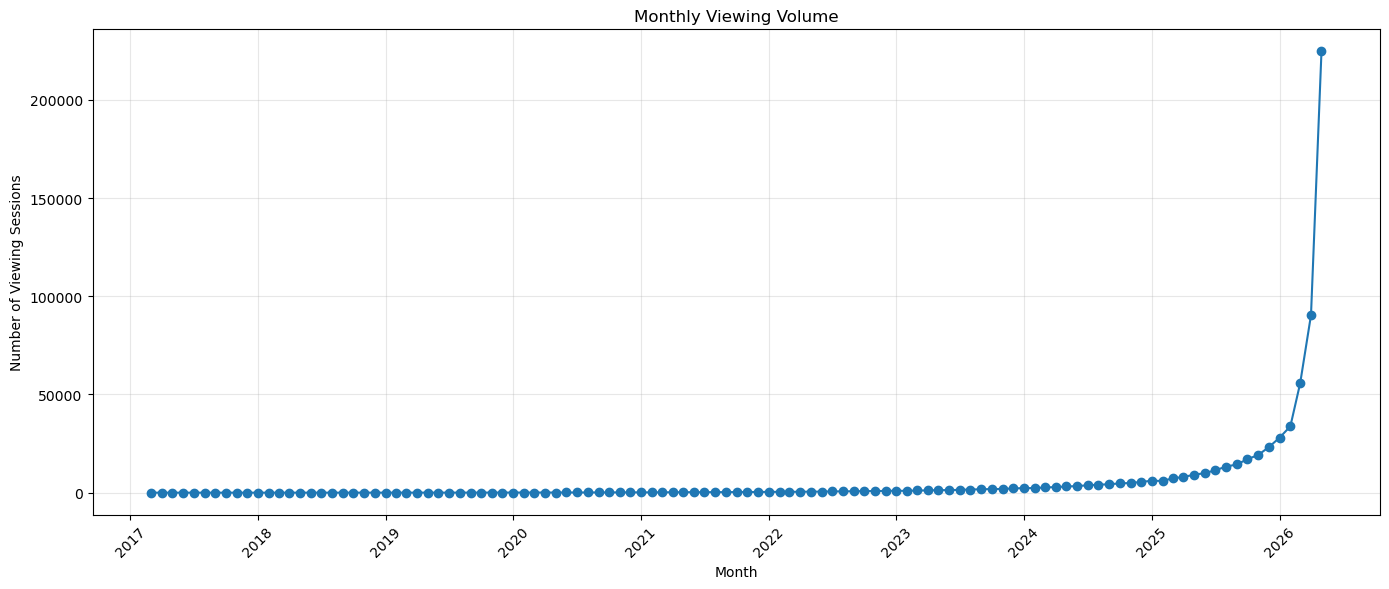

In [19]:
monthly_sessions = (
    watch_history
    .dropna(subset=["watch_date"])
    .set_index("watch_date")
    .resample("MS")
    .size()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sessions.index,
    monthly_sessions.values,
    marker="o"
)

plt.title("Monthly Viewing Volume")
plt.xlabel("Month")
plt.ylabel("Number of Viewing Sessions")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "01_monthly_viewing_volume.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The chart shows variation in monthly viewing activity across the StreamFlix
timeline. The busiest month was [MONTH YEAR], with approximately [NUMBER]
viewing sessions.

### CHART 2 — Monthly Watch Hours
This chart shows the total number of hours watched each month.

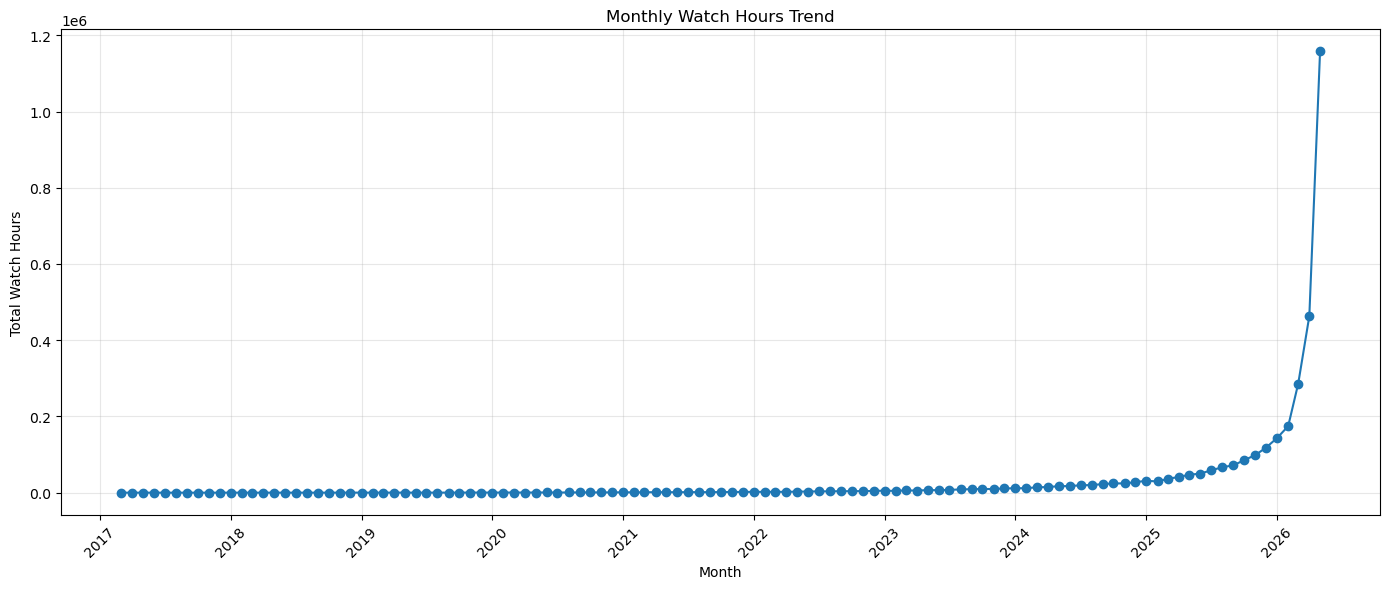

In [21]:
monthly_watch_hours = (
    watch_history
    .dropna(subset=["watch_date"])
    .set_index("watch_date")["watch_hours"]
    .resample("MS")
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_watch_hours.index,
    monthly_watch_hours.values,
    marker="o"
)

plt.title("Monthly Watch Hours Trend")
plt.xlabel("Month")
plt.ylabel("Total Watch Hours")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "02_monthly_watch_hours.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 3 — Genre-wise Watch Hour


In [26]:
genre_watch = watch_history.merge(
    titles[["title_id", "primary_genre", "type"]],
    on="title_id",
    how="left"
)

print("genre_watch created successfully!")
print(genre_watch.columns.tolist())

genre_watch created successfully!
['watch_id', 'subscriber_id', 'title_id', 'watch_date', 'device', 'region', 'content_duration_min', 'watch_duration_min', 'completion_pct', 'completed', 'calculated_completion_pct', 'completion_difference', 'watch_hours', 'primary_genre', 'type']


In [27]:
print(genre_watch["type"].value_counts(dropna=False))

type
Movie      382330
TV Show    267670
Name: count, dtype: int64


In [28]:
content_type_hours = (
    genre_watch
    .groupby("type")["watch_hours"]
    .sum()
    .sort_values(ascending=False)
)

print(content_type_hours)

type
TV Show    2.882609e+06
Movie      4.508588e+05
Name: watch_hours, dtype: float64


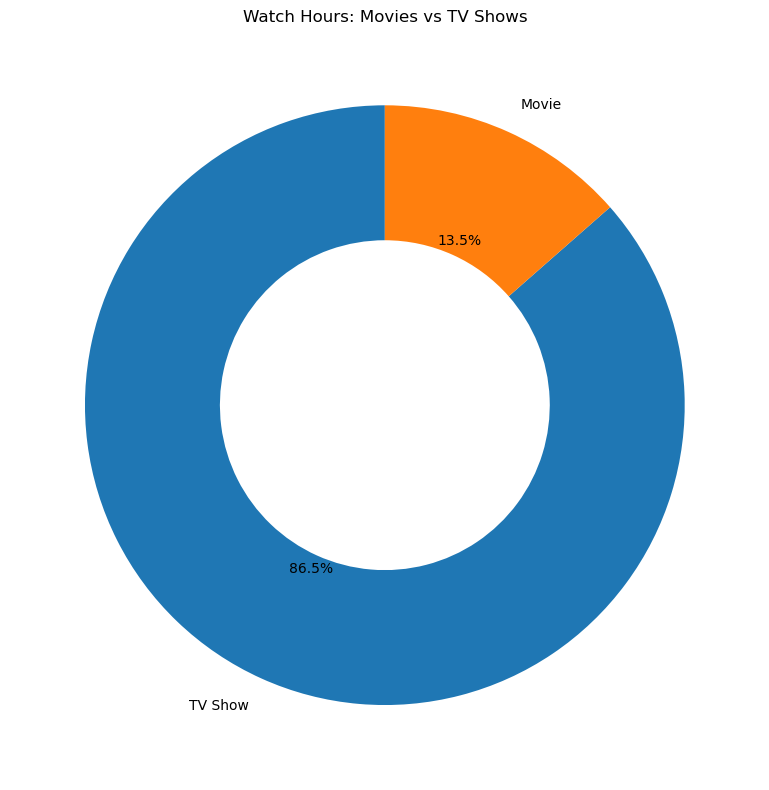

In [29]:
plt.figure(figsize=(8, 8))

plt.pie(
    content_type_hours.values,
    labels=content_type_hours.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Watch Hours: Movies vs TV Shows")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "04_content_type_split.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 4 — Movies vs TV Shows

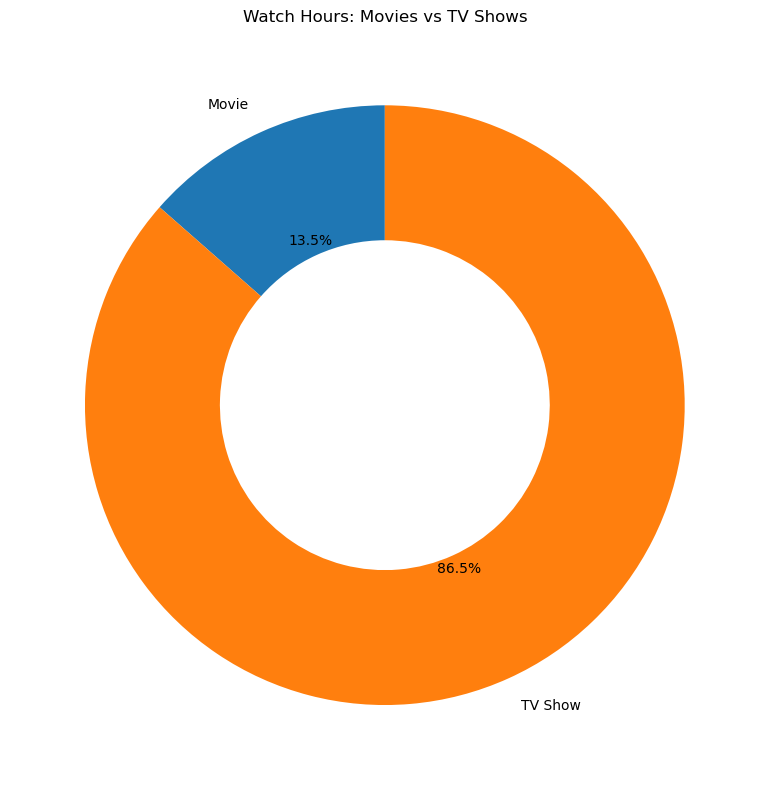

In [30]:
content_type_hours = (
    genre_watch
    .groupby("type")["watch_hours"]
    .sum()
)

plt.figure(figsize=(8, 8))

plt.pie(
    content_type_hours,
    labels=content_type_hours.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Watch Hours: Movies vs TV Shows")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "04_content_type_split.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 5 — Top 10 Countries

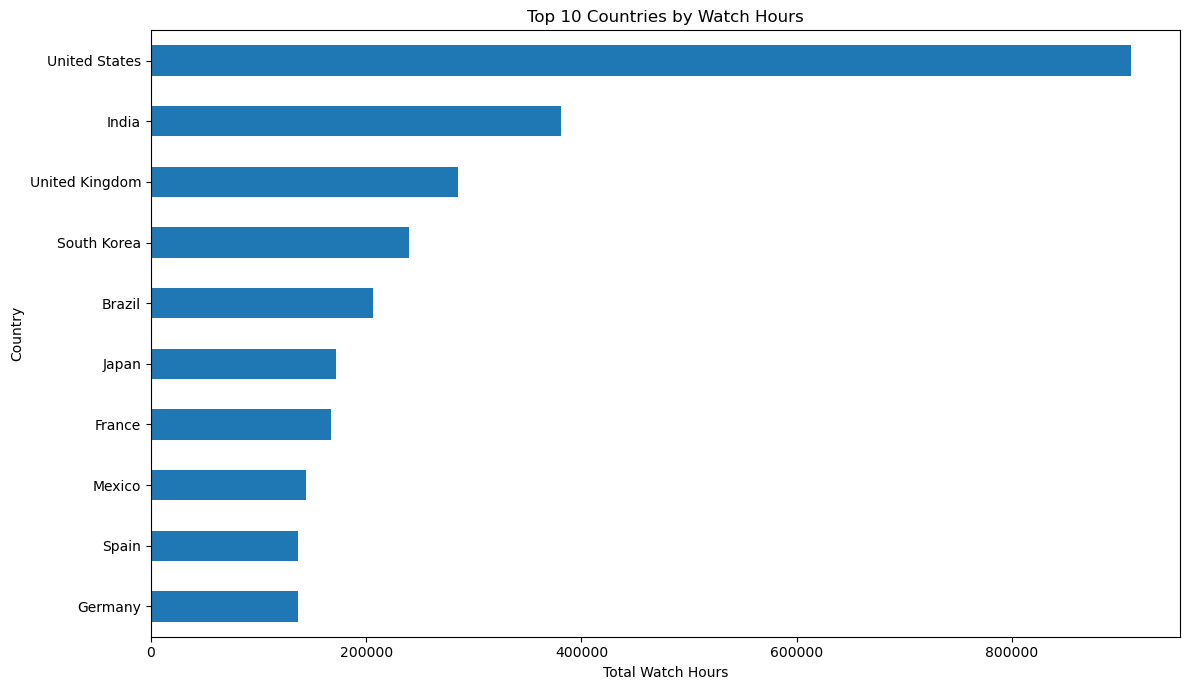

In [31]:
country_watch = watch_history.merge(
    subscribers[["subscriber_id", "country"]],
    on="subscriber_id",
    how="left"
)

country_hours = (
    country_watch
    .groupby("country")["watch_hours"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

country_hours.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Watch Hours")
plt.xlabel("Total Watch Hours")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "05_top_10_countries.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 6 — Subscriber Plan Distribution

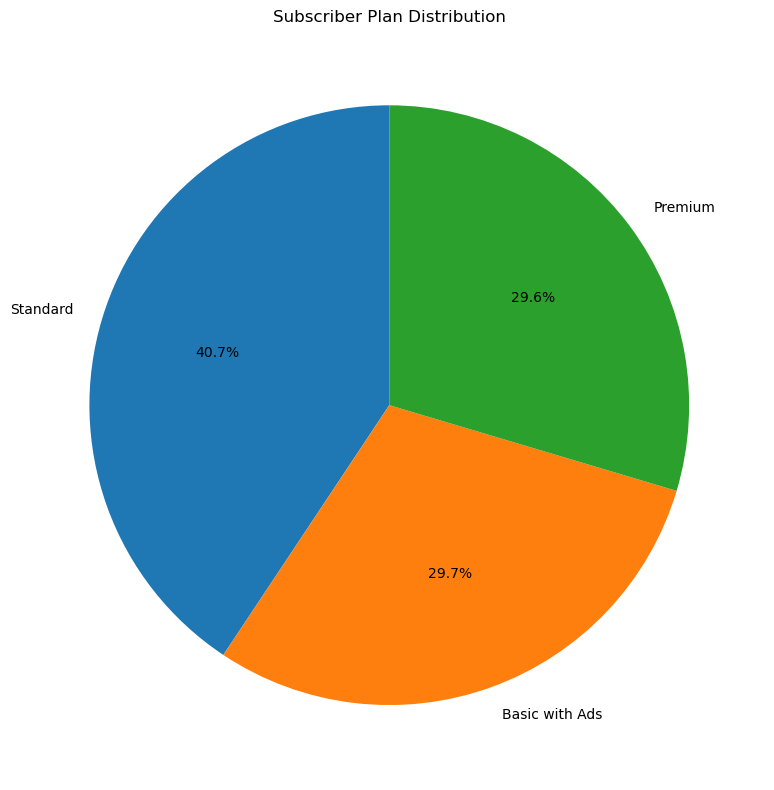

In [32]:
plan_counts = subscribers["plan_type"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    plan_counts,
    labels=plan_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Subscriber Plan Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "06_subscriber_plan_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 7 — Device Usage

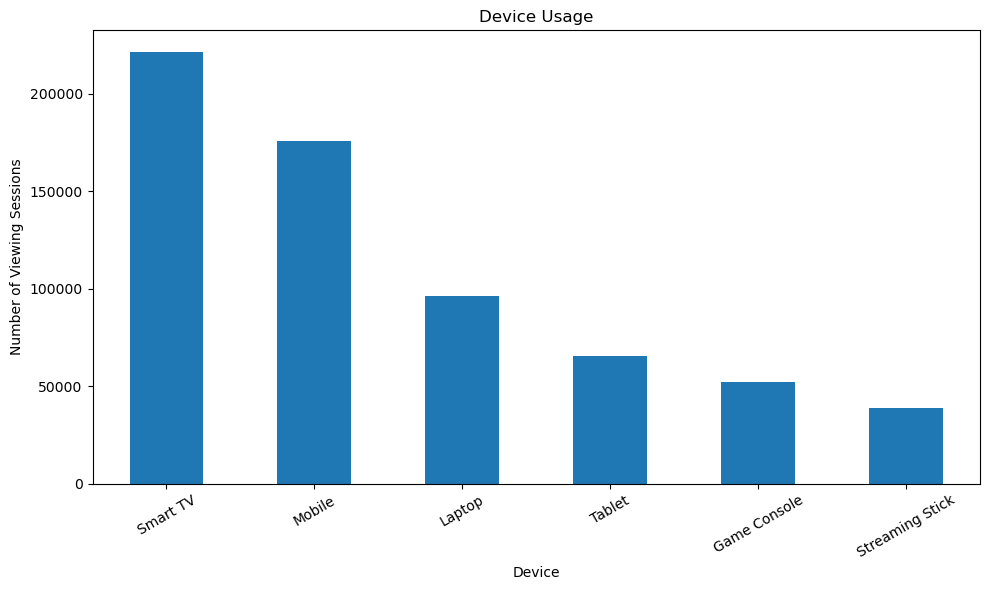

In [33]:
device_counts = (
    watch_history["device"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

device_counts.plot(
    kind="bar"
)

plt.title("Device Usage")
plt.xlabel("Device")
plt.ylabel("Number of Viewing Sessions")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "07_device_usage.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 8 — Age Distribution

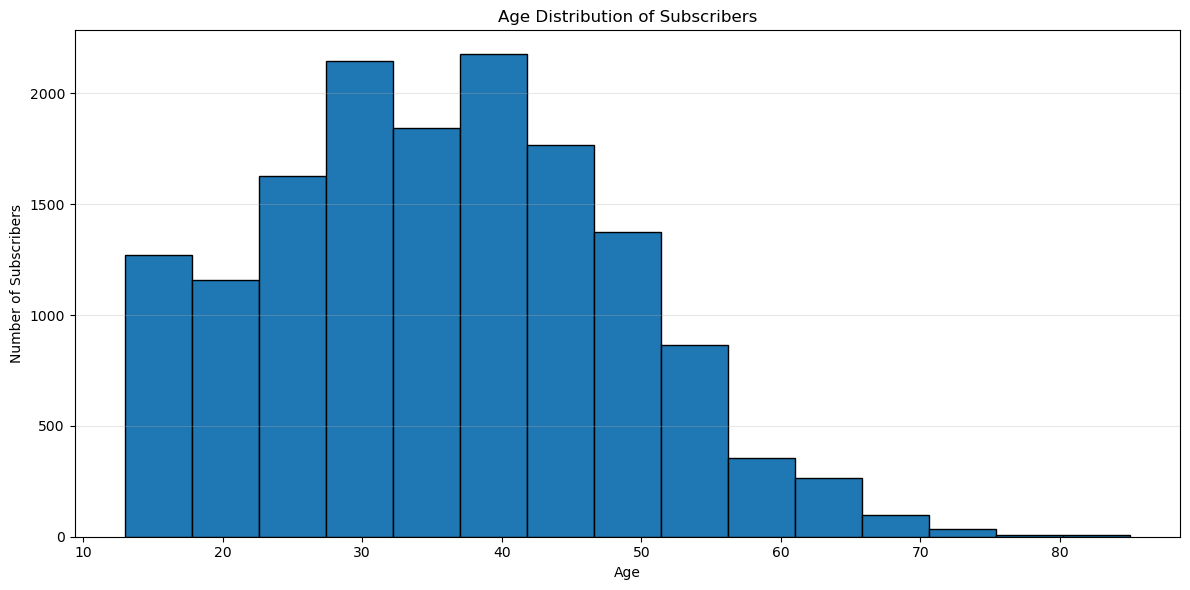

In [34]:
plt.figure(figsize=(12, 6))

plt.hist(
    subscribers["age"].dropna(),
    bins=15,
    edgecolor="black"
)

plt.title("Age Distribution of Subscribers")
plt.xlabel("Age")
plt.ylabel("Number of Subscribers")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "08_age_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 9 — Completion Rate by Genre

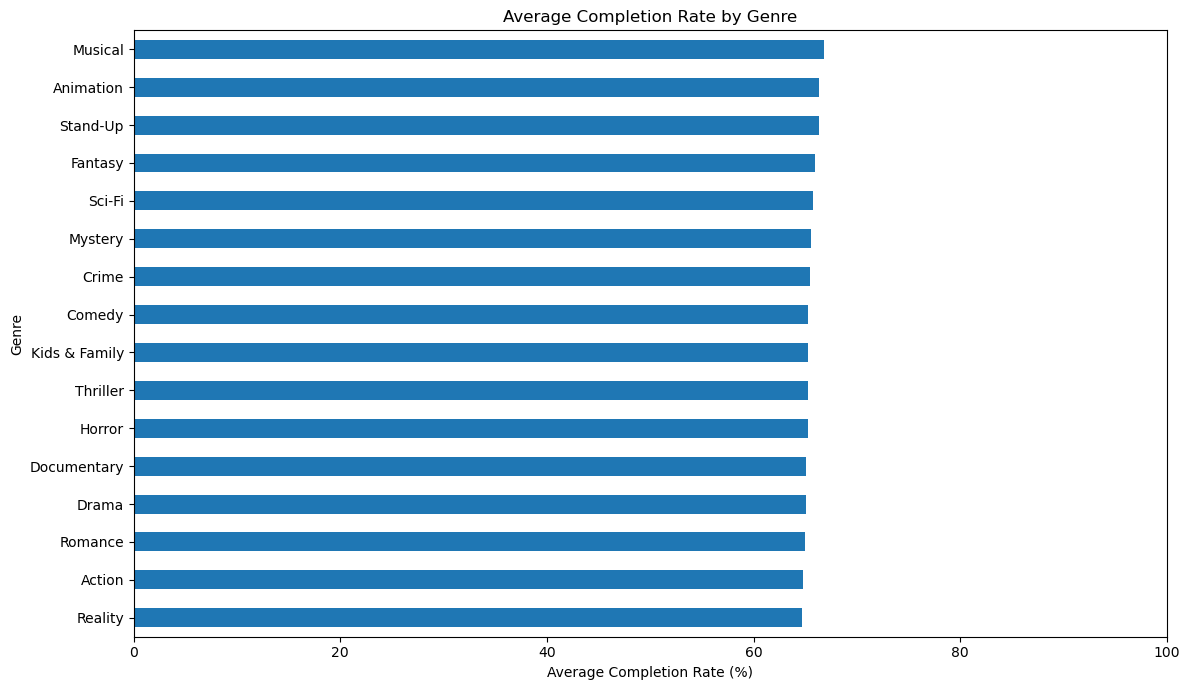

In [35]:
completion_genre = watch_history.merge(
    titles[["title_id", "primary_genre"]],
    on="title_id",
    how="left"
)

genre_completion = (
    completion_genre
    .groupby("primary_genre")["completion_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

genre_completion.sort_values().plot(
    kind="barh"
)

plt.title("Average Completion Rate by Genre")
plt.xlabel("Average Completion Rate (%)")
plt.ylabel("Genre")

plt.xlim(0, 100)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "09_completion_rate_by_genre.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 10 — Review Sentiment

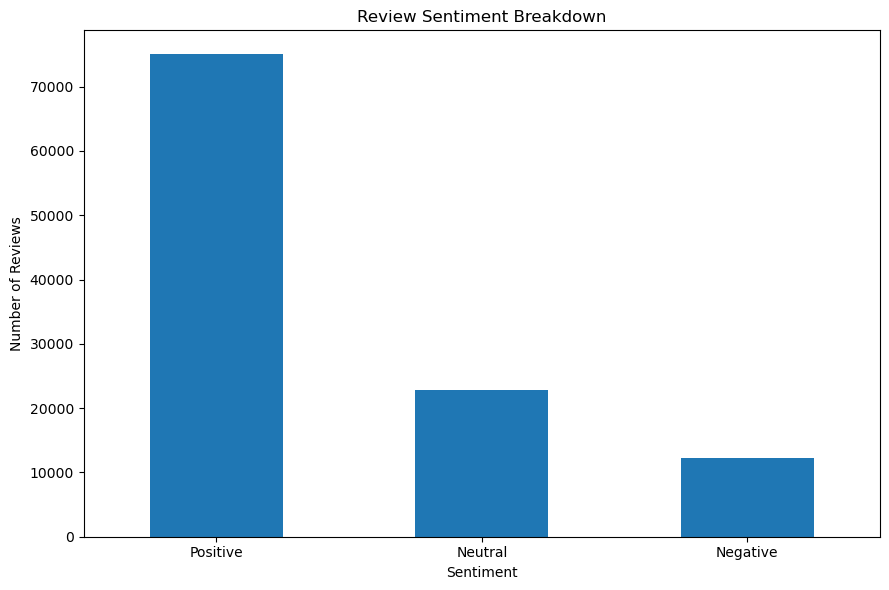

In [36]:
sentiment_counts = (
    reviews["sentiment"]
    .value_counts()
    .reindex(
        ["Positive", "Neutral", "Negative"],
        fill_value=0
)

)

plt.figure(figsize=(9, 6))

sentiment_counts.plot(
    kind="bar"
)

plt.title("Review Sentiment Breakdown")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "10_review_sentiment_breakdown.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Check all 10 charts

In [37]:
print("Saved PNG charts:\n")

for file in sorted(os.listdir(CHART_PATH)):
    if file.endswith(".png"):
        print("✓", file)

Saved PNG charts:

✓ 01_monthly_viewing_volume.png
✓ 02_monthly_watch_hours.png
✓ 03_genre_watch_hours.png
✓ 04_content_type_split.png
✓ 05_top_10_countries.png
✓ 06_subscriber_plan_distribution.png
✓ 07_device_usage.png
✓ 08_age_distribution.png
✓ 09_completion_rate_by_genre.png
✓ 10_review_sentiment_breakdown.png
